In [1]:
import fastf1
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
from xgboost import XGBClassifier, XGBRegressor, plot_importance
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr
import shap
import matplotlib.pyplot as plt

/Users/dimkostir/Desktop/Projects/f1-predictions/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = pd.read_parquet('/Users/dimkostir/Desktop/Projects/f1-predictions/data/processed/master_tables/master_table_phase2_24_25.parquet')

In [5]:
print(f"FP2 features shape: {data.shape}")
print(f"Master Phase 2 shape: {data.shape}")
print(f"\nColumns in master2:\n{data.columns.tolist()}")
print(f"\nNull counts:\n{data.isnull().sum()}")

FP2 features shape: (958, 12)
Master Phase 2 shape: (958, 12)

Columns in master2:
['Driver', 'TeamName_x', 'GridPosition', 'Finish_Position', 'Status', 'delta_to_pole', 'Qual_Position', 'Year', 'Location', 'fp2_median_pace', 'fp2_team_dif', 'fp2_deg_rate']

Null counts:
Driver               0
TeamName_x           0
GridPosition         0
Finish_Position      0
Status               0
delta_to_pole       11
Qual_Position        1
Year                 0
Location             0
fp2_median_pace    298
fp2_team_dif       310
fp2_deg_rate       354
dtype: int64


In [46]:
training_data = data[data["Year"] == 2024]
test_data = data[data["Year"] == 2025]

X_train = training_data.drop(columns = ["Driver", "TeamName_x", "Status", "Year", "Location", "Finish_Position"], axis = 1)
y_train = training_data["Finish_Position"].astype(int)

X_test = test_data.drop(columns = ["Driver", "TeamName_x", "Status", "Year", "Location", "Finish_Position"], axis = 1)
y_test = test_data["Finish_Position"].astype(int)

bst = XGBRegressor(n_estimators = 200, max_depth = 4, learning_rate = 0.01)
bst.fit(X_train, y_train)

predictions = bst.predict(X_test)

In [47]:
test_data = test_data.copy()
test_data["Prediction"] = predictions

spearman_per_race = test_data.groupby("Location").apply(
    lambda x: spearmanr(x["Finish_Position"], x["Prediction"])[0]
)

print(spearman_per_race)
print(f"\Avg Spearman: {spearman_per_race.mean():.3f}")

Location
Austin               0.770504
Baku                 0.804511
Barcelona            0.608772
Budapest             0.823618
Imola                0.708537
Jeddah               0.706767
Las Vegas            0.040602
Lusail               0.630034
Marina Bay           0.771429
Melbourne            0.479699
Mexico City          0.688981
Miami Gardens        0.841551
Monaco               0.784962
Montréal             0.673684
Monza                0.737871
Sakhir               0.700752
Shanghai             0.444613
Silverstone          0.479699
Spa-Francorchamps    0.706326
Spielberg            0.635509
Suzuka               0.962350
São Paulo            0.591422
Yas Island           0.855639
Zandvoort            0.174436
dtype: float64
\Avg Spearman: 0.651


/var/folders/s0/k6p2569n6w1br5pz86sgwm400000gn/T/ipykernel_2069/2250314883.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  spearman_per_race = test_data.groupby("Location").apply(


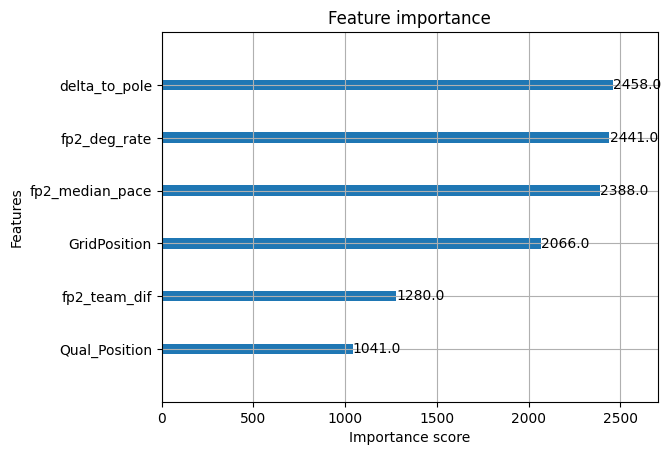

In [30]:
plot_importance(bst)
plt.show()

In [27]:
test = fastf1.get_session(2026,1,'R')
test.load()
test.results


core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1', '3', '87', '41', '5', '10', '31', '23', '30', '43', '55', '11', '18', '14', '77', '6', '81', '27']


,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
63,63,G RUSSELL,RUS,russell,Mercedes,00D7B6,mercedes,George,Russell,George Russell,...,1.0,1,1.0,NaT,NaT,NaT,0 days 01:23:06.801000,Finished,25.0,58.0
12,12,K ANTONELLI,ANT,antonelli,Mercedes,00D7B6,mercedes,Kimi,Antonelli,Kimi Antonelli,...,2.0,2,2.0,NaT,NaT,NaT,0 days 00:00:02.974000,Finished,18.0,58.0
16,16,C LECLERC,LEC,leclerc,Ferrari,ED1131,ferrari,Charles,Leclerc,Charles Leclerc,...,3.0,3,4.0,NaT,NaT,NaT,0 days 00:00:15.519000,Finished,15.0,58.0
44,44,L HAMILTON,HAM,hamilton,Ferrari,ED1131,ferrari,Lewis,Hamilton,Lewis Hamilton,...,4.0,4,7.0,NaT,NaT,NaT,0 days 00:00:16.144000,Finished,12.0,58.0
1,1,L NORRIS,NOR,norris,McLaren,F47600,mclaren,Lando,Norris,Lando Norris,...,5.0,5,6.0,NaT,NaT,NaT,0 days 00:00:51.741000,Finished,10.0,58.0
3,3,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,4781D7,red_bull,Max,Verstappen,Max Verstappen,...,6.0,6,20.0,NaT,NaT,NaT,0 days 00:00:54.617000,Finished,8.0,58.0
87,87,O BEARMAN,BEA,bearman,Haas F1 Team,9C9FA2,haas,Oliver,Bearman,Oliver Bearman,...,7.0,7,12.0,NaT,NaT,NaT,0 days 00:00:04.593000,Lapped,6.0,57.0
41,41,A LINDBLAD,LIN,arvid_lindblad,Racing Bulls,6C98FF,rb,Arvid,Lindblad,Arvid Lindblad,...,8.0,8,9.0,NaT,NaT,NaT,0 days 00:00:11.816000,Lapped,4.0,57.0
5,5,G BORTOLETO,BOR,bortoleto,Audi,F50537,audi,Gabriel,Bortoleto,Gabriel Bortoleto,...,9.0,9,10.0,NaT,NaT,NaT,0 days 00:00:12.775000,Lapped,2.0,57.0
10,10,P GASLY,GAS,gasly,Alpine,00A1E8,alpine,Pierre,Gasly,Pierre Gasly,...,10.0,10,14.0,NaT,NaT,NaT,0 days 00:00:29.027000,Lapped,1.0,57.0
